# Pregunta 1 — Ruido Poisson y filtrado Gaussiano adaptativo

Importo las liberias

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Esto es para generar la imágen que me piden

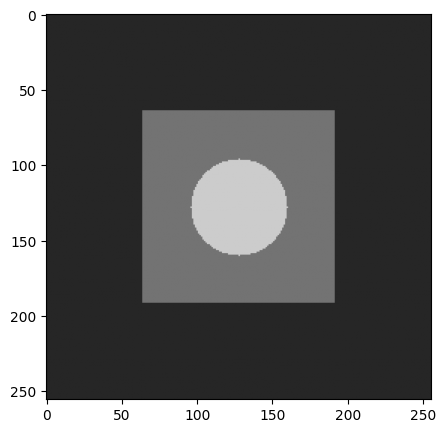

In [2]:
#tamaño
N = 256
cx = 128
cy = 128  #centross

#genera vectores de coordenadas para tenerlo de base apra la imagen
Y, X = np.ogrid[:N, :N]
imagenprueba = np.full((N, N), 0.15) #lleno el fondo con la intensidad pedida


#cuadrado
cuadrado = (X >= 64) & (X < 192) & (Y >= 64) & (Y < 192)
#circulo
circulo = (X - cx)**2 + (Y - cy)**2 <= 32**2


#las tres mascaras
mascirculo = circulo
mascuadrado = cuadrado & ~mascirculo
masfondo = ~cuadrado

#mascaras e intensidades
imagenprueba[mascuadrado] = 0.45         
imagenprueba[mascirculo] = 0.80   

# imagen final
plt.figure(figsize=(5, 5))
plt.imshow(imagenprueba, cmap='gray', vmin=0, vmax=1)
plt.show()


Acá podemos ver las máscaras que pedian

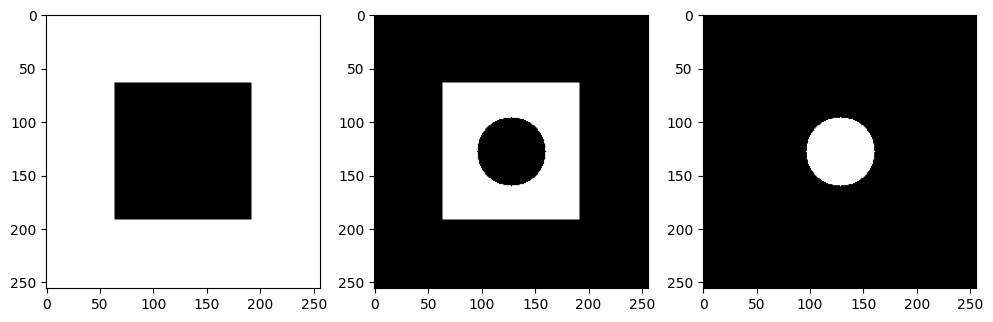

In [3]:
#mascaras
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(masfondo, cmap='gray', vmin=0, vmax=1)

axs[1].imshow(mascuadrado, cmap='gray', vmin=0, vmax=1)

axs[2].imshow(mascirculo, cmap='gray', vmin=0, vmax=1)

plt.show()

y le aplicamos el ruido

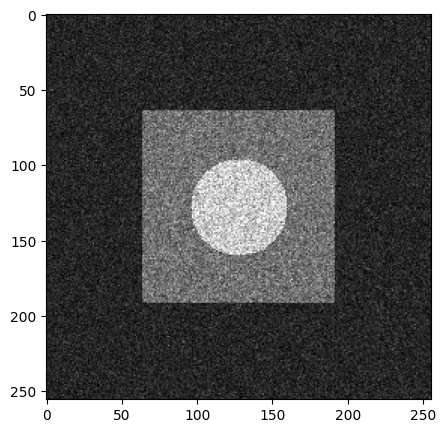

In [4]:
#busco la forma de crear la semilla aleatoria
np.random.seed(1)
#N = 40 para el ruido
Npoiss = 40

#genero la imágen ruidosa
ruidosa = np.random.poisson(Npoiss * imagenprueba) / Npoiss

# imagen final
plt.figure(figsize=(5, 5))
plt.imshow(ruidosa, cmap='gray', vmin=0, vmax=1)
plt.show()

función para calcular el kernel que se pide

In [5]:

def kernelgauss(sigma):
    if sigma == 0: #estp es para evitar la división por 0 al reemplazar
        return np.array([[1]]) 
        
    radio = int(2* sigma)
    tamano = 2 * radio + 1
    
    kernel = np.zeros((tamano, tamano))
    suma = 0
    
    for i in range(tamano):
        for j in range(tamano):
            x = i - radio
            y = j - radio
            
            # Usamos np.exp en lugar de math.exp para no requerir otra librería
            valor = np.exp(-(x**2 + y**2) / (2 * sigma**2))
            kernel[i, j] = valor
            suma += valor
    resultado =   kernel / suma   
    return resultado

Y otra para el RMSE que piden más adelante

In [6]:
def RMSE(ideal, filtro, mascara):
    yti = ideal[mascara]
    yi = filtro[mascara]
    error = (yti - yi)**2
    mse = np.mean(error)
    rmse = np.sqrt(mse)
    
    return rmse


In [7]:
from scipy.signal import convolve2d

creo la función para aplicar el filtro con el sigma a elegir

In [8]:
def aplicarfiltro(imagen, sigma):
    matriz = kernelgauss(sigma)
    
    # agrego mode = "same" para que no vaya a cambiar de tamaño
    filtrada = convolve2d(imagen, matriz, mode='same')
    return filtrada


Esto es para la parte de experimentacion y análisis

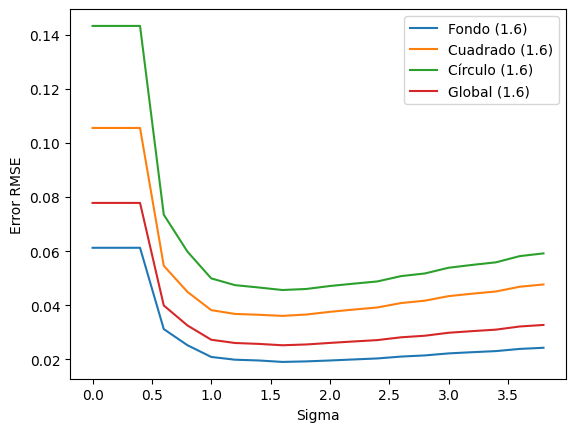

In [9]:
sigmas = np.arange(0, 4, 0.2) 

rmsefondo = []
rmsecuadrado = []
rmsecirculo = []
rmseglobal = []

for i in sigmas:
    if i == 0:
        filtrada = ruidosa
    else:
        filtrada = aplicarfiltro(ruidosa, i) 
        
    rmsefondo.append(RMSE(imagenprueba, filtrada, masfondo))
    rmsecuadrado.append(RMSE(imagenprueba, filtrada, mascuadrado))
    rmsecirculo.append(RMSE(imagenprueba, filtrada, mascirculo))
    #la condicion >= 0 es para tomar todos los pixeles de la imagen
    rmseglobal.append(RMSE(imagenprueba, filtrada, ruidosa >= 0))

minfondo = sigmas[np.argmin(rmsefondo)]
mincuadrado = sigmas[np.argmin(rmsecuadrado)]
mincirculo = sigmas[np.argmin(rmsecirculo)]
minglobal = sigmas[np.argmin(rmseglobal)]

#calculo donde ocurren valores valores minimos
plt.plot(sigmas, rmsefondo, label=f'Fondo ({minfondo:.1f})')
plt.plot(sigmas, rmsecuadrado, label=f'Cuadrado ({mincuadrado:.1f})')
plt.plot(sigmas, rmsecirculo, label=f'Círculo ({mincirculo:.1f})')
plt.plot(sigmas, rmseglobal, label=f'Global ({minglobal:.1f})')

plt.xlabel('Sigma')
plt.ylabel('Error RMSE')
plt.legend()
plt.show()

Para el punto 4, diseñé la siguiente regla explicada en el informe

In [10]:
def Fu(mu):
    #las intensidades definidas en el enunciado
    intensidades = [0.15, 0.45, 0.8]
    #tomo como valor intermedio el 0,45 y le asigno el sigma comun 1,6 
    valoressigma = [0.8, 1.6, 2.4] 
    
    #preferí definir una interpolación antes de una función por 
    #tramos para que los bordes sean más suaves
    
    mapa = np.interp(mu, intensidades, valoressigma)
    
    return mapa

Ahora para el punto 5 aplico filtro gaussiano dependiendo el pixel y la configuración de los sigmas, lo que permite que sea efectivamente un filtro adaptativo.

In [13]:
def filtroadaptativo(imagen, sigmas):
    resultado = imagen.copy()
    filas, columnas = imagen.shape
    radio = 3 #defino un radio prudente para poder realizar el difuminado
    tamano = 2 * radio + 1
    
    for i in range(radio, filas - radio):
        for j in range(radio, columnas - radio):
            sigma = sigmas[i, j]
            # como hay una división por sigma, debo poner esta  condición para no tener errores
            if sigma > 0: 
                kernel = np.zeros((tamano, tamano))
                suma = 0
                
                # Construimos el kernel paso a paso según la distancia al centro
                for f in range(tamano):
                    for c in range(tamano):
                        x = f - radio
                        y = c - radio
                        
                        valor = np.exp(-(x**2 + y**2) / (2 * sigma**2))
                        kernel[f, c] = valor
                        suma += valor
                        
                kernel = kernel / suma #esto es para normalizar
                
                #limites del vecindario
                inicioi = i - radio
                fini = i + radio + 1

                inicioj = j - radio
                finj = j + radio + 1
                
                vecindario = imagen[inicioi:fini, inicioj:finj]
                
                #filtro para el pixel del centro
                resultado[i, j] = np.sum(vecindario * kernel)
                
    return resultado

In [15]:
# ocupo mi imagen ruidosa con el sigma qe minimisa el error
mu = aplicarfiltro(ruidosa, 1.6)

# a partir de la estimación saco mis valores de sigma
sigmas = Fu(mu)

#y filto la imágen con el filtro adaptativo
imagenadaptativa = filtroadaptativo(ruidosa, sigmas)


In [22]:

#nuevamente cálculo de errores
rmseadapfondo = RMSE(imagenprueba, imagenadaptativa, masfondo)
rmseadapcuadrado = RMSE(imagenprueba, imagenadaptativa, mascuadrado)
rmseadapcirculo = RMSE(imagenprueba, imagenadaptativa, mascirculo)
rmseadapglobal = RMSE(imagenprueba, imagenadaptativa, ruidosa >= 0)

#comparo los valores de los errores
print("RMSE Global v/s Adaptativo:")
print(f"Fondo: {min(rmsefondo):.4f} / {rmseadapfondo:.4f}")
print(f"Cuadrado: {min(rmsecuadrado):.4f} / {rmseadapcuadrado:.4f}")
print(f"Circulo: {min(rmsecirculo):.4f} / {rmseadapcirculo:.4f}")
print(f"Total: {min(rmseglobal):.4f} / {rmseadapglobal:.4f}")



RMSE Global v/s Adaptativo:
Fondo: 0.0191 / 0.0274
Cuadrado: 0.0361 / 0.0353
Circulo: 0.0456 / 0.0470
Total: 0.0252 / 0.0303


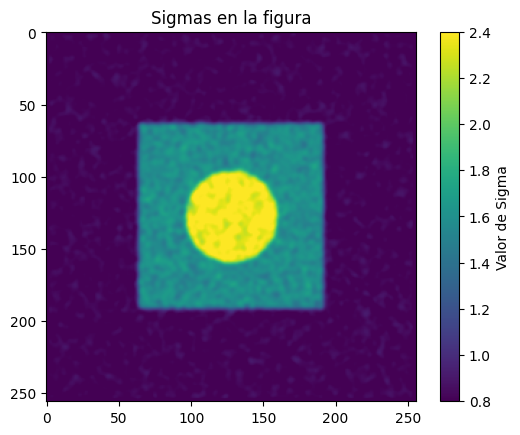

In [21]:
# 6. Graficar el mapa de sigmas
plt.imshow(sigmas, cmap='viridis')
plt.colorbar(label='Valor de Sigma')
plt.title('Sigmas en la figura')
plt.show()

Para pregunta guiada:

In [25]:

print(f"Fondo / mu: {mu[249, 249]:.2f} | sigma: {sigmas[249, 249]:.2f}")


print(f"Cuadrado / mu: {mu[170, 170]:.2f} | sigma: {sigmas[170, 170]:.2f}")


print(f"Círculo / mu: {mu[125, 125]:.2f} | sigma: {sigmas[125, 125]:.2f}")

Fondo / mu: 0.17 | sigma: 0.84
Cuadrado / mu: 0.47 | sigma: 1.64
Círculo / mu: 0.84 | sigma: 2.40
